In [10]:
import sys
import os
import pandas as pd

# Get the absolute path of the project root directory
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

In [2]:
import pickle
import os

# Define the directory and file path
save_dir = "../data/parsed/"
load_path = os.path.join(save_dir, "builder.pkl")

# Load the builder object
with open(load_path, "rb") as f:
    builder = pickle.load(f)

In [3]:
sample = builder.run(builder.timestamps[8759])

In [4]:
sample

This pandapower network includes the following parameter tables:
   - bus (118 elements)
   - load (91 elements)
   - gen (321 elements)
   - ext_grid (1 element)
   - line (177 elements)
   - trafo (9 elements)
   - bus_geodata (118 elements)
 and the following results tables:
   - res_bus (118 elements)
   - res_line (177 elements)
   - res_trafo (9 elements)
   - res_ext_grid (1 element)
   - res_load (91 elements)
   - res_gen (321 elements)

Shape: (321, 8760)

First few entries:
                         2024-01-01 00:00:00  2024-01-01 01:00:00  \
generator   bus type                                                
biomass_001 11  biomass             0.520871             0.523649   
biomass_002 11  biomass             0.520871             0.523649   
biomass_003 102 biomass             0.248849             0.249590   
biomass_004 102 biomass             0.248849             0.249590   
biomass_005 11  biomass             0.224156             0.224765   

                         2024-01-01 02:00:00  2024-01-01 03:00:00  \
generator   bus type                                                
biomass_001 11  biomass             0.525106             0.525611   
biomass_002 11  biomass             0.525106             0.525611   
biomass_003 102 biomass             0.249845             0.249930   
biomass_004 102 biomass             0.249845             0.249930   
biomass_005 11  biomass             0.225138             0.2253

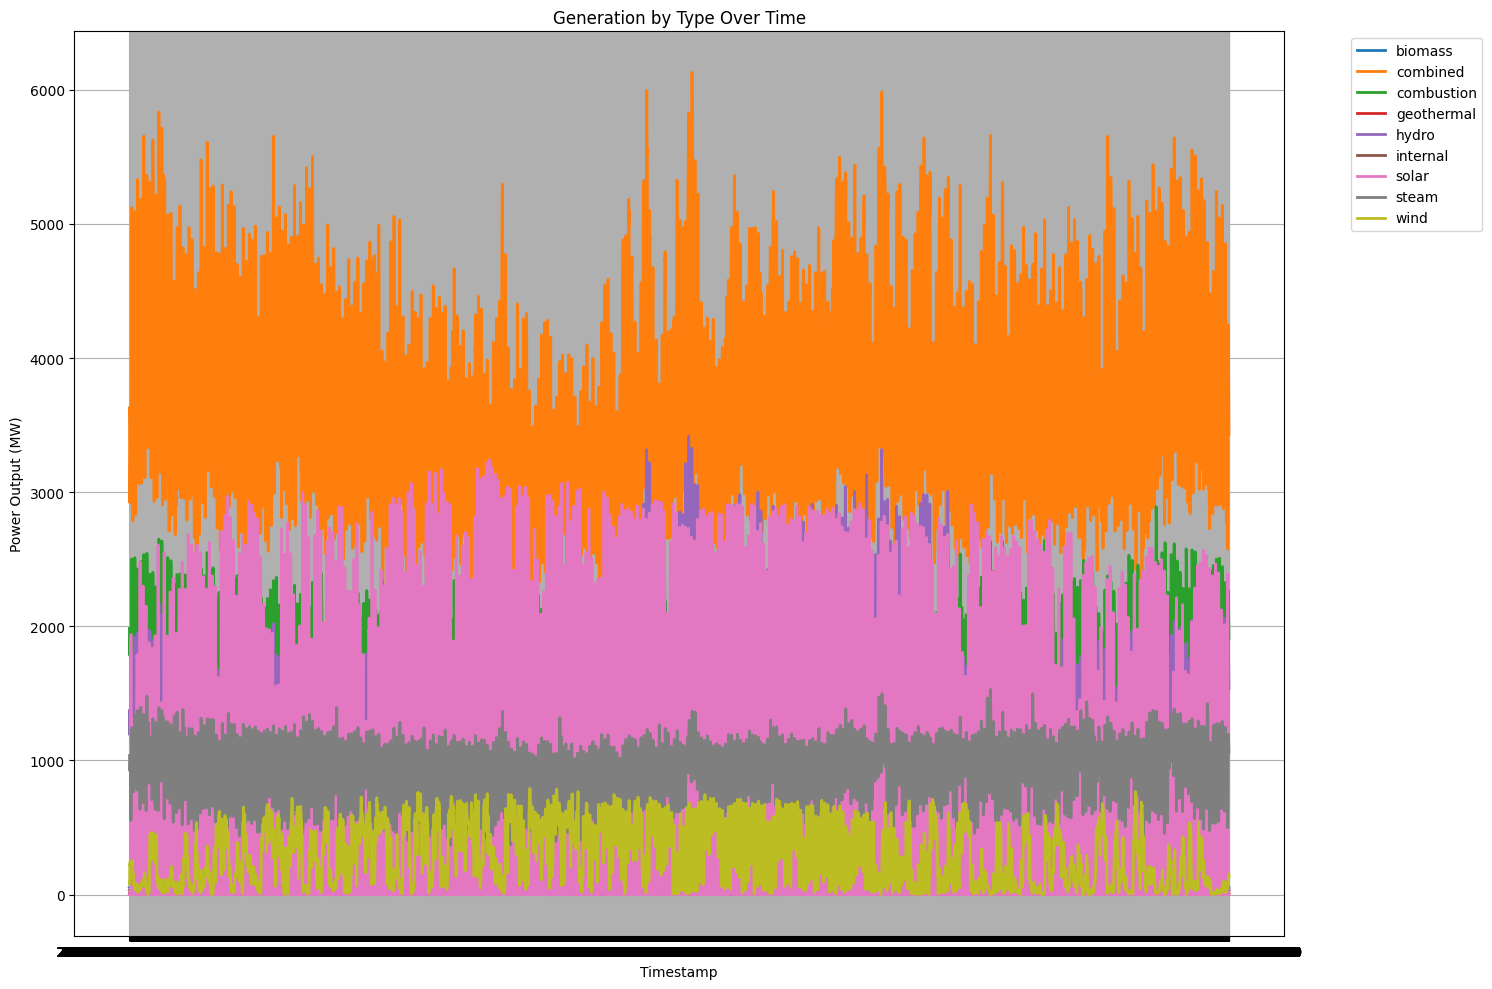


Summary Statistics by Generator Type:
       2024-01-01 00:00:00  2024-01-01 01:00:00  2024-01-01 02:00:00  \
count         9.000000e+00         9.000000e+00         9.000000e+00   
mean          9.104651e+02         8.938324e+02         8.145885e+02   
std           1.255218e+03         1.217674e+03         1.089076e+03   
min          -4.096113e-11        -1.250299e-10         7.508421e-11   
25%           3.285554e+01         3.210655e+01         3.187231e+01   
50%           7.974731e+01         9.880042e+01         1.142895e+02   
75%           1.370983e+03         1.350723e+03         1.212503e+03   
max           3.628255e+03         3.504528e+03         3.110570e+03   

       2024-01-01 03:00:00  2024-01-01 04:00:00  2024-01-01 05:00:00  \
count         9.000000e+00         9.000000e+00         9.000000e+00   
mean          7.953454e+02         7.930015e+02         8.083225e+02   
std           1.029106e+03         1.023943e+03         1.039546e+03   
min          -3.520832e-

In [8]:
def create_generator_output_matrix(builder, num_timestamps=24):  # Default to first 24 hours
    """
    Creates a DataFrame of generator outputs across specified timesteps.
    
    Args:
        builder: PandaPowerFlowBuilder instance
        num_timestamps: Number of timestamps to process
        
    Returns:
        DataFrame where:
        - Index is MultiIndex (generator_name, bus_number, type)
        - Columns are timestamps
        - Values are generator outputs (p_mw)
    """
    # Get first sample to identify all generators
    sample = builder.run(builder.timestamps[0])
    
    # Create generator info with type extracted from name
    generator_info = sample.gen[['name', 'bus']].copy()
    generator_info['type'] = generator_info['name'].apply(lambda x: x.split('_')[0])
    
    multi_index = pd.MultiIndex.from_frame(
        generator_info, 
        names=['generator', 'bus', 'type']
    )
    
    # Use limited number of timestamps
    timestamps = builder.timestamps[:num_timestamps]
    
    # Initialize DataFrame with zeros
    output_matrix = pd.DataFrame(
        index=multi_index,
        columns=timestamps,
        dtype=float
    )
    
    # Fill the matrix with generator outputs for each timestamp
    for timestamp in timestamps:
        sample = builder.run(timestamp)
        output_matrix[timestamp] = sample.res_gen['p_mw'].values
    
    return output_matrix

def plot_generation_by_type(output_matrix):
    """
    Creates plots showing generation by type over time.
    """
    import matplotlib.pyplot as plt
    
    # Aggregate by type
    type_totals = output_matrix.groupby(level='type').sum()
    
    # Create figure
    plt.figure(figsize=(15, 10))
    
    # Plot each type
    for gen_type in type_totals.index:
        plt.plot(type_totals.loc[gen_type], label=gen_type, linewidth=2)
    
    plt.title('Generation by Type Over Time')
    plt.xlabel('Timestamp')
    plt.ylabel('Power Output (MW)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nSummary Statistics by Generator Type:")
    print(type_totals.describe())
    
    return type_totals

# Create the matrix for first 24 hours
generator_output_matrix = create_generator_output_matrix(builder, num_timestamps=8760)

# Display the first few entries
print("Shape:", generator_output_matrix.shape)
print("\nFirst few entries:")
print(generator_output_matrix.iloc[:5, :5])

# Plot generation by type
type_totals = plot_generation_by_type(generator_output_matrix)

In [9]:
def plot_generation_by_type_plotly(output_matrix):
    """
    Creates enhanced interactive visualizations showing generation by type over time using Plotly.
    """
    import pandas as pd
    import plotly.graph_objects as go
    import plotly.express as px
    from plotly.subplots import make_subplots
    import numpy as np
    
    # Aggregate by type
    type_totals = output_matrix.groupby(level='type').sum()
    
    # Convert timestamp columns to datetime if they aren't already
    if not isinstance(type_totals.columns[0], pd.Timestamp):
        type_totals.columns = pd.to_datetime(type_totals.columns)
    
    # Set a more appealing color palette
    colors = {
        'solar': '#FFD700',    # Gold
        'wind': '#87CEEB',     # Sky Blue
        'hydro': '#1E90FF',    # Dodger Blue
        'nuclear': '#800080',  # Purple
        'gas': '#FF6347',      # Tomato
        'coal': '#696969',     # Dim Gray
        'biomass': '#228B22',  # Forest Green
        'geothermal': '#8B4513', # Saddle Brown
        'oil': '#A52A2A',      # Brown
        'battery': '#32CD32',  # Lime Green
    }
    
    # Sort by average output (larger generators at bottom for stacked area)
    sorted_types = type_totals.mean(axis=1).sort_values().index.tolist()
    
    # Create a figure with subplots
    fig = make_subplots(
        rows=2, cols=2,
        specs=[[{"colspan": 2}, None], [{"type": "xy"}, {"type": "domain"}]],
        subplot_titles=('Power Generation by Type', 'Top 5 Generation Sources', 'Generation Mix'),
        row_heights=[0.6, 0.4],
        vertical_spacing=0.12,
        horizontal_spacing=0.05
    )
    
    # Get timestamps for x-axis
    timestamps = type_totals.columns.tolist()
    
    # 1. STACKED AREA PLOT
    # Create the stacked area plot
    for gen_type in sorted_types:
        fig.add_trace(
            go.Scatter(
                x=timestamps,
                y=type_totals.loc[gen_type].values,
                mode='lines',
                name=gen_type,
                line=dict(width=0.5, color=colors.get(gen_type, px.colors.qualitative.Plotly[sorted_types.index(gen_type) % len(px.colors.qualitative.Plotly)])),
                stackgroup='one',  # This makes it a stacked area chart
                hovertemplate='%{x}<br>%{y:.1f} MW<extra>' + gen_type + '</extra>'
            ),
            row=1, col=1
        )
    
    # Calculate and show total generation
    total_generation = type_totals.sum()
    fig.add_trace(
        go.Scatter(
            x=timestamps,
            y=total_generation.values,
            mode='lines',
            name='Total',
            line=dict(color='black', width=2),
            hovertemplate='%{x}<br>Total: %{y:.1f} MW<extra></extra>'
        ),
        row=1, col=1
    )
    
    # 2. LINE PLOT FOR INDIVIDUAL CONTRIBUTIONS
    # Get top 5 contributors by average output
    top_generators = type_totals.mean(axis=1).nlargest(5).index
    
    for gen_type in top_generators:
        fig.add_trace(
            go.Scatter(
                x=timestamps,
                y=type_totals.loc[gen_type].values,
                mode='lines',
                name=gen_type + ' (detail)',
                line=dict(
                    color=colors.get(gen_type, px.colors.qualitative.Plotly[sorted_types.index(gen_type) % len(px.colors.qualitative.Plotly)]),
                    width=2
                ),
                hovertemplate='%{x}<br>%{y:.1f} MW<extra>' + gen_type + '</extra>',
                showlegend=False  # Hide from legend since it's in the stacked area
            ),
            row=2, col=1
        )
    
    # 3. PIE CHART FOR GENERATION MIX
    # Calculate summary statistics
    stats_df = type_totals.T.describe().T
    stats_df['capacity_factor'] = stats_df['mean'] / stats_df['max'] * 100
    stats_df['contribution_pct'] = stats_df['mean'] / stats_df['mean'].sum() * 100
    stats_df = stats_df.sort_values('contribution_pct', ascending=False)
    
    # Add pie chart for generation mix
    pie_colors = [colors.get(t, px.colors.qualitative.Plotly[sorted_types.index(t) % len(px.colors.qualitative.Plotly)]) 
                 for t in stats_df.index]
    
    fig.add_trace(
        go.Pie(
            labels=stats_df.index,
            values=stats_df['contribution_pct'],
            textinfo='label+percent',
            hoverinfo='label+percent+value',
            hovertemplate='%{label}<br>%{value:.1f}%<extra></extra>',
            marker=dict(colors=pie_colors),
            showlegend=False
        ),
        row=2, col=2
    )
    
    # Update layout for better appearance
    fig.update_layout(
        height=800,
        width=1000,
        title={
            'text': 'Power Generation Analysis',
            'font': {'size': 24},
            'y': 0.98,
            'x': 0.5,
            'xanchor': 'center',
            'yanchor': 'top'
        },
        legend={
            'orientation': 'h',
            'yanchor': 'bottom',
            'y': 1.02,
            'xanchor': 'right',
            'x': 1
        },
        hovermode='closest',
        template='plotly_white'
    )
    
    # Update axes
    fig.update_xaxes(
        title_text='Timestamp',
        showgrid=True,
        gridwidth=0.5,
        gridcolor='lightgray',
        row=1, col=1
    )
    
    fig.update_yaxes(
        title_text='Power Output (MW)',
        showgrid=True,
        gridwidth=0.5,
        gridcolor='lightgray',
        row=1, col=1
    )
    
    fig.update_xaxes(
        title_text='Timestamp',
        showgrid=True,
        gridwidth=0.5,
        gridcolor='lightgray',
        row=2, col=1
    )
    
    fig.update_yaxes(
        title_text='Power Output (MW)',
        showgrid=True,
        gridwidth=0.5,
        gridcolor='lightgray',
        row=2, col=1
    )
    
    # Print summary statistics
    print("\nSummary Statistics by Generator Type:")
    formatted_stats = stats_df[['mean', 'max', 'min', 'std', 'capacity_factor', 'contribution_pct']]
    formatted_stats.columns = ['Avg (MW)', 'Max (MW)', 'Min (MW)', 'Std Dev', 'Capacity Factor (%)', 'Generation Mix (%)']
    
    print(formatted_stats.round(2))
    
    # Create additional table visualization
    summary_table = go.Figure(data=[
        go.Table(
            header=dict(
                values=['Generator Type', 'Avg (MW)', 'Max (MW)', 'Min (MW)', 
                        'Capacity Factor (%)', 'Generation Mix (%)'],
                font=dict(size=12, color='white'),
                fill_color='#1f77b4',
                align='left'
            ),
            cells=dict(
                values=[
                    stats_df.index,
                    stats_df['mean'].round(1),
                    stats_df['max'].round(1),
                    stats_df['min'].round(1),
                    stats_df['capacity_factor'].round(1),
                    stats_df['contribution_pct'].round(1)
                ],
                font=dict(size=11),
                align='left',
                format=[None, '.1f', '.1f', '.1f', '.1f', '.1f']
            )
        )
    ])
    
    summary_table.update_layout(
        title="Generation Summary Statistics",
        height=400,
        width=800
    )
    
    # Show both figures
    fig.show()
    summary_table.show()
    
    return type_totals, fig, summary_table

# Use the improved Plotly visualization
type_totals, fig, summary_table = plot_generation_by_type_plotly(generator_output_matrix)


Summary Statistics by Generator Type:
            Avg (MW)  Max (MW)  Min (MW)  Std Dev  Capacity Factor (%)  \
type                                                                     
combined     3607.68   6129.59   1901.89   726.52                58.86   
combustion   1729.68   2891.57    869.10   334.79                59.82   
hydro        1568.44   3416.51    874.03   394.43                45.91   
steam         922.97   1530.10    342.05   206.63                60.32   
solar         774.10   3240.00     -0.00  1001.48                23.89   
wind          292.33    791.17      0.00   225.63                36.95   
biomass        50.21     75.57     23.63    10.84                66.44   
internal       32.54     50.00     17.12     4.13                65.08   
geothermal      9.30     16.00      0.00     3.44                58.10   

            Generation Mix (%)  
type                            
combined                 40.14  
combustion               19.25  
hydro         